# LSTM Model

- En este código hago el split aleatorio mezclando escenarios, cuidando que las ventanas no se superpongan entre los diferentes sets. Por eso, primero genero los DataFrames de cada set con runs distintos y luego creo las ventanas. Con esto me aseguro de que no haya ventanas superpuestas entre train, test y validation, evitando así obtener datos engañosos.
- He agregado el parámetro window_step para poder cambiar el paso de generación de ventanas.
- Utilizo los datos que tienen definida la T_confort como una mezcla de T_air y T_surf. ¿Probar poner ambas por separado como target?
- He agregado el parámetro step para controlar el avance temporal de las ventanas.
- Convierto el problema a residual forecasting para mejorar respecto al baseline fuerte.
- Agregué más runs para aumentar el número de escenarios y permitir que el modelo aprenda una dinámica real y causal del edificio.

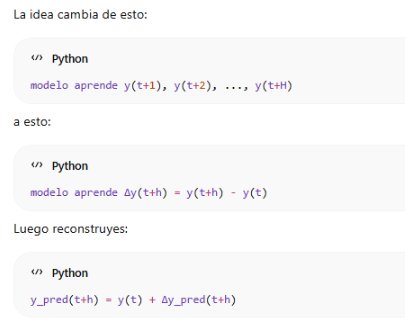

In [3]:
import pandas as pd

dfs1 = []
for i in [0,1,3,4,5,2]:
    dfi  = pd.read_csv(f"CSV/df_runs/df_runs_{i}.csv", encoding="latin1")
    print(dfi['run_id'].unique())
    dfs1.append(dfi)

[0]
[1]
[3]
[4]
[5]
[2]


In [4]:
dfs2 = []
for i in range(6,22):
    dfi  = pd.read_csv(f"CSV/df_runs/df_runs_{i}.csv", encoding="latin1")
    print(dfi['run_id'].unique())
    dfs2.append(dfi)

[6]
[7]
[8]
[9]
[10]
[11]
[12]
[13]
[14]
[15]
[16]
[17]
[18]
[19]
[20]
[21]


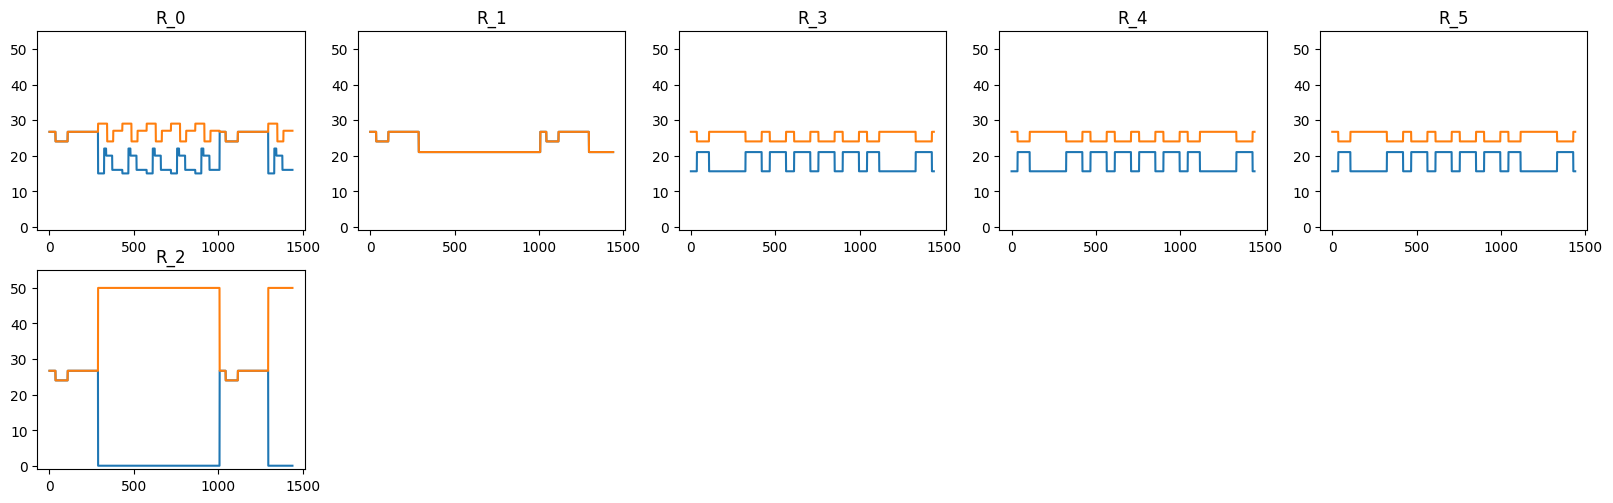

In [5]:

import matplotlib.pyplot as plt

runs1 = ['R_0','R_1','R_3','R_4','R_5','R_2']
plt.figure(figsize=(20, 15))

for i in range(len(dfs1)):
    plt.subplot(5,5,i+1)
    plt.title(runs1[i])
    dfs1[i]['termostatos_Clases101_Heating'][:1440].plot()
    dfs1[i]['termostatos_Clases101_Cooling'][:1440].plot()
    plt.ylim(-1, 55)   # ejemplo

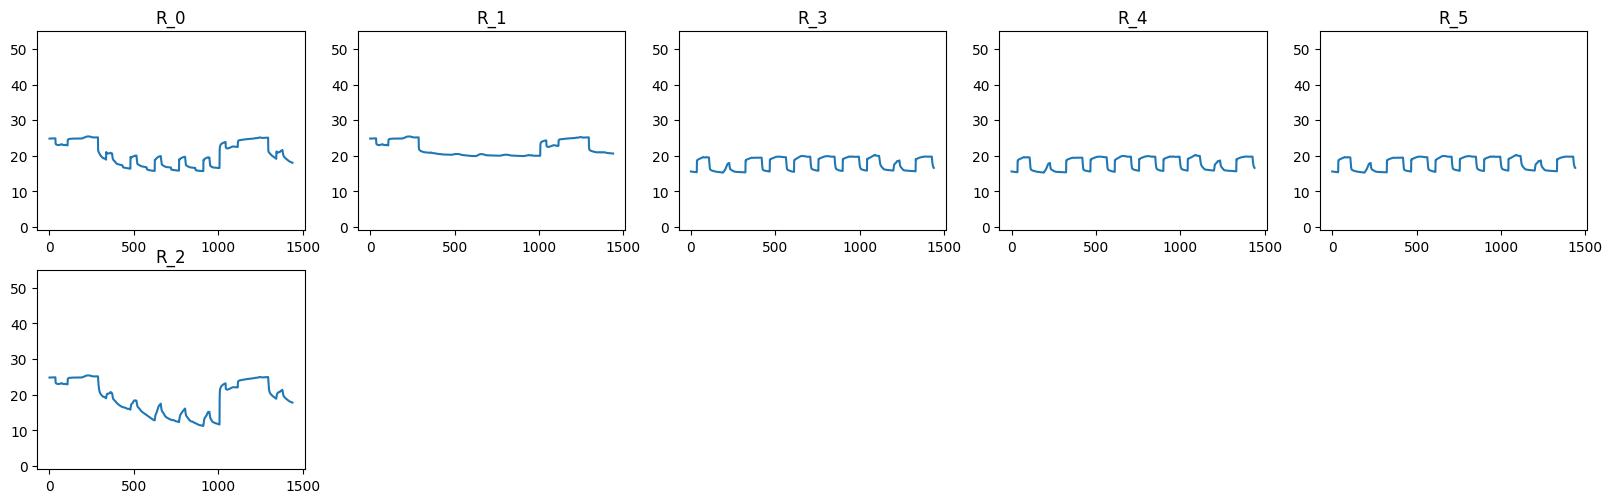

In [6]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))

for i in range(len(dfs1)):
    plt.subplot(5,5,i+1)
    plt.title(runs1[i])
    dfs1[i]['T_confort'][:1440].plot()
    plt.ylim(-1, 55)   # ejemplo

In [7]:
selected_scenarios1 = [
'R_0','R_3','R_4','R_5'
]

indices1 = [runs1.index(x) for x in selected_scenarios1]

print(indices1)

selected_dfs1 = [dfs1[i] for i in indices1]

[0, 2, 3, 4]


In [8]:
df_total1 = pd.concat(selected_dfs1, ignore_index=True)

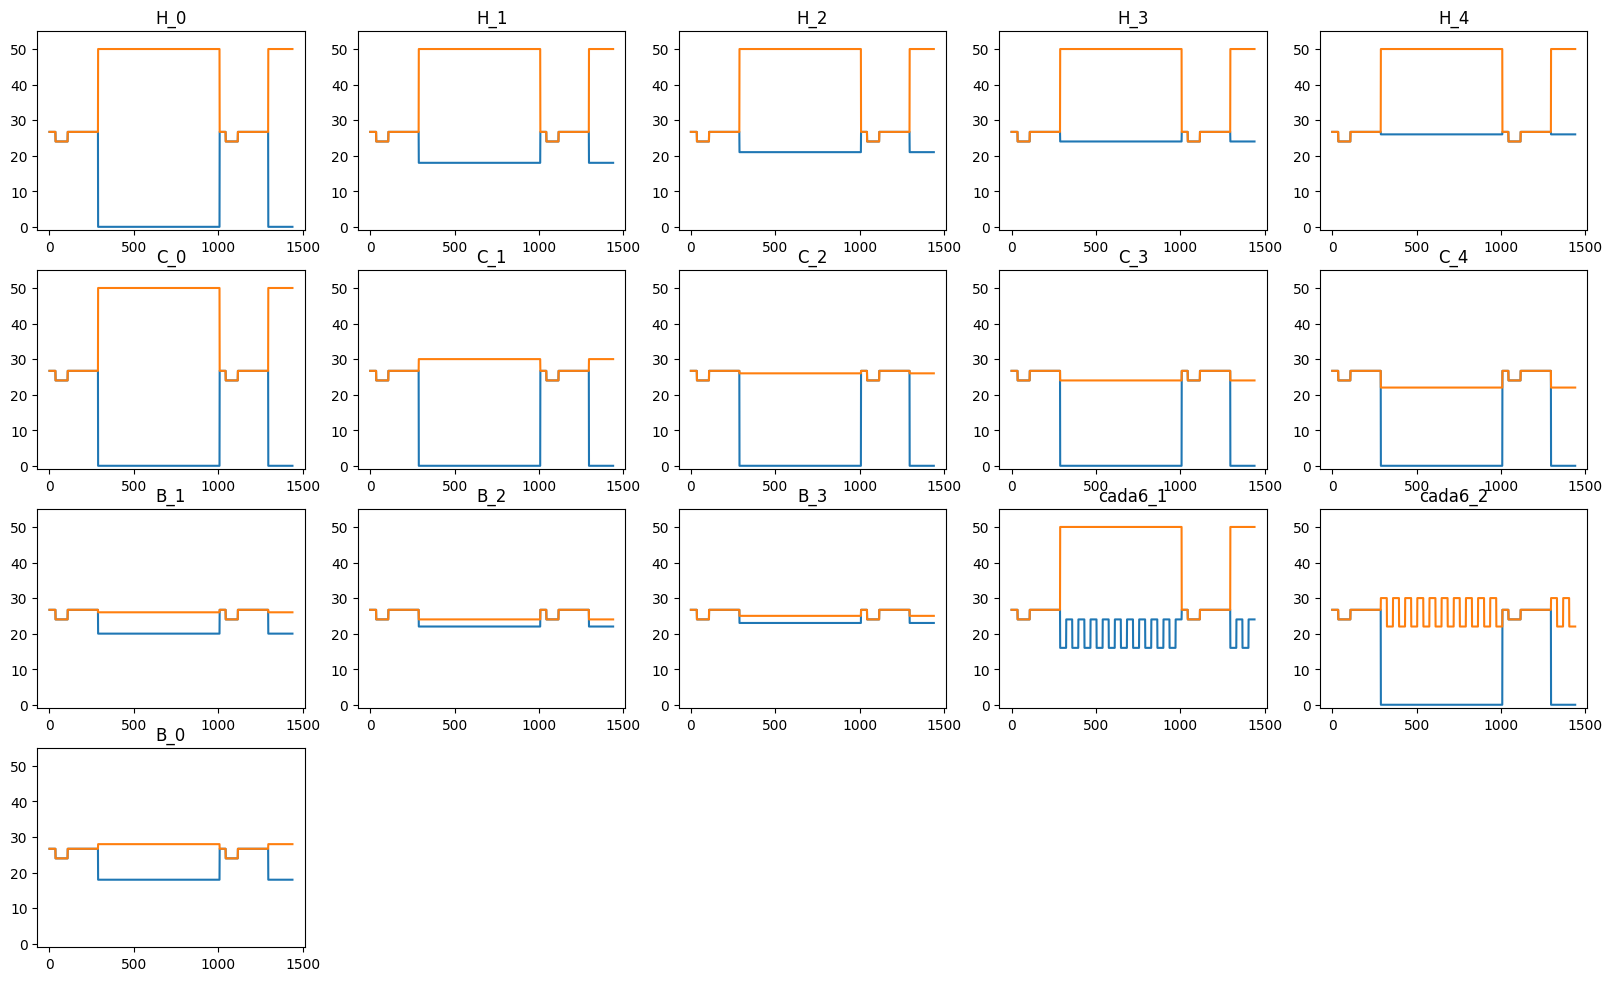

In [9]:
import matplotlib.pyplot as plt

runs2 = ['H_0','H_1','H_2','H_3','H_4','C_0','C_1','C_2','C_3','C_4','B_1','B_2','B_3','cada6_1','cada6_2','B_0']
plt.figure(figsize=(20, 15))

for i in range(len(dfs2)):
    plt.subplot(5,5,i+1)
    plt.title(runs2[i])
    dfs2[i]['termostatos_Clases101_Heating'][:1440].plot()
    dfs2[i]['termostatos_Clases101_Cooling'][:1440].plot()
    plt.ylim(-1, 55)   # ejemplo

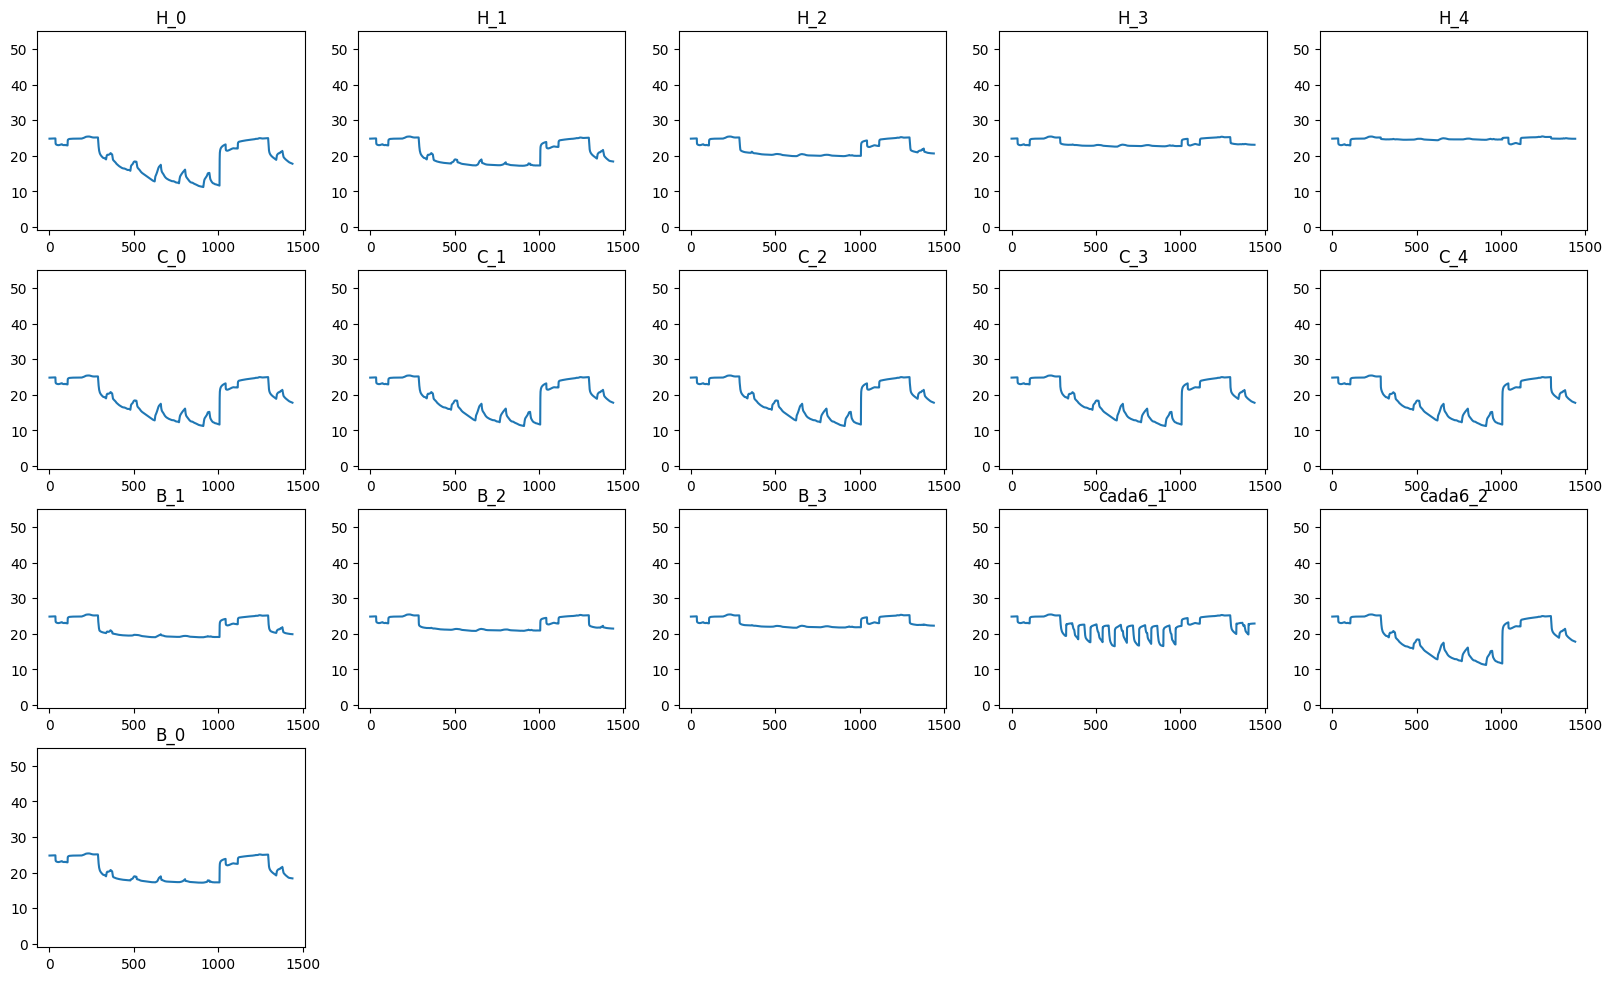

In [10]:
plt.figure(figsize=(20, 15))

for i in range(len(dfs2)):
    plt.subplot(5,5,i+1)
    plt.title(runs2[i])
    dfs2[i]['T_confort'][:1440].plot()
    plt.ylim(-1, 55)   # ejemplo

In [11]:
selected_scenarios2 = [
'H_1','H_4','C_0','C_4','B_3','cada6_1','cada6_2','B_0'
]

# selected_scenarios2 = runs2
indices2 = [runs2.index(x) for x in selected_scenarios2]

print(indices2)

selected_dfs2 = [dfs2[i] for i in indices2]

[1, 4, 5, 9, 12, 13, 14, 15]


In [12]:
df_total2 = pd.concat(selected_dfs2, ignore_index=True)

In [13]:
df_total2['run_id'].unique()

array([ 7, 10, 11, 15, 18, 19, 20, 21])

In [14]:
df_total = pd.concat([df_total1,df_total2], ignore_index=True)

In [15]:
df_total['run_id'].unique()

array([ 0,  3,  4,  5,  7, 10, 11, 15, 18, 19, 20, 21])

In [16]:
df_total[[
    "termostatos_Taller_Heating",
    "termostatos_Taller_Cooling",
    "T_confort"
]].corr()

,termostatos_Taller_Heating,termostatos_Taller_Cooling,T_confort
termostatos_Taller_Heating,1.000000,-0.057966,0.466646
termostatos_Taller_Cooling,-0.057966,1.000000,0.162242
T_confort,0.466646,0.162242,1.000000


In [17]:
df_total[[
    "termostatos_Taller_Heating",
    "termostatos_Taller_Cooling",
    "T_confort"
]].describe()

,termostatos_Taller_Heating,termostatos_Taller_Cooling,T_confort
count,630720.000000,630720.000000,630720.000000
mean,17.534288,31.236012,22.376037
std,8.957805,10.641385,3.175223
min,0.000000,20.000000,9.232248
25%,15.600000,24.000000,20.104330
50%,21.000000,26.700000,22.780143
75%,24.000000,30.000000,24.906732
max,26.700000,50.000000,32.516072


- La correlacion de cooling sigue siendo algo baja.
- Necesitamos mas escenarios en donde se active el cooling.

In [18]:
'''
Los termostatos son iguales en todas las zonas, me quedo solo con los del taller como target.
'''

import re
import numpy as np

def get_columns(columns, key):
    
    columns_key = []
    for col in columns:
        
        if re.search(f'{key}', col, re.IGNORECASE) and not re.search('Taller', col, re.IGNORECASE) :
            columns_key.append(col)
    
    # Prints
    print(f'{key} len = {len(columns_key)}')
    
    return columns_key


Remove_termostatos = get_columns(df_total.columns, 'termostatos')

termostatos len = 14


In [19]:
df_total = df_total.drop(Remove_termostatos, axis = 1)

In [20]:
df_total.head(4)

,Unnamed: 0.1,Unnamed: 0,datetime,Air_temp_banos,Air_Temp_Taller,Tsurf_mean_Banos,Tsurf_mean_Hall,Tsurf_mean_Paillo,Tsurf_mean_Paillo_ventanas,Tsurf_mean_Taller,...,Precipitarion_Depth,solar_radiation,Illuminance,termostatos_Taller_Heating,termostatos_Taller_Cooling,run_id,T_confort,Air_temp_clases_pasillo_Hall,CO2_clases_bano,CO2_hall_pasillo
0,0,0,1900-01-01 00:10:00,18.566637,26.7,21.067453,23.376186,23.491973,10.767394,22.883942,...,0.000022,0.0,0.0,26.7,26.7,0,24.791971,26.7,410.218877,404.818591
1,1,1,1900-01-01 00:20:00,18.561686,26.7,21.067193,23.379545,23.498098,11.249103,22.887119,...,0.000044,0.0,0.0,26.7,26.7,0,24.793559,26.7,409.675648,404.393052
2,2,2,1900-01-01 00:30:00,18.556385,26.7,21.067050,23.383808,23.505211,11.780097,22.891085,...,0.000067,0.0,0.0,26.7,26.7,0,24.795542,26.7,409.161664,404.005580
3,3,3,1900-01-01 00:40:00,18.551011,26.7,21.067049,23.388981,23.513168,12.344575,22.895778,...,0.000089,0.0,0.0,26.7,26.7,0,24.797889,26.7,408.675305,403.652705


In [21]:
df_2 = df_total.copy()

df_2 = df_2.drop(['Unnamed: 0'], axis = 1)
df_2 = df_2.dropna().reset_index(drop=True)

# df_2.columns

In [32]:
df_2.head()

,Unnamed: 0.1,datetime,Air_temp_banos,Air_Temp_Taller,Tsurf_mean_Banos,Tsurf_mean_Hall,Tsurf_mean_Paillo,Tsurf_mean_Paillo_ventanas,Tsurf_mean_Taller,Tsurf_mean_Taller_ventanas,...,T_confort,Air_temp_clases_pasillo_Hall,CO2_clases_bano,CO2_hall_pasillo,DíaSemana_sin,DíaSemana_cos,Hour_sin,Hour_cos,Month_sin,Month_cos
0,52559,1900-01-01 00:00:00,18.119268,26.7,20.452868,22.884391,23.052658,15.450282,22.307404,15.084329,...,24.503702,26.7,412.106286,405.555872,0.0,1.0,0.0,1.0,0.0,1.0
1,0,1900-01-01 00:10:00,18.566637,26.7,21.067453,23.376186,23.491973,10.767394,22.883942,10.595607,...,24.791971,26.7,410.218877,404.818591,0.0,1.0,0.0,1.0,0.0,1.0
2,1,1900-01-01 00:20:00,18.561686,26.7,21.067193,23.379545,23.498098,11.249103,22.887119,11.009831,...,24.793559,26.7,409.675648,404.393052,0.0,1.0,0.0,1.0,0.0,1.0
3,2,1900-01-01 00:30:00,18.556385,26.7,21.067050,23.383808,23.505211,11.780097,22.891085,11.473153,...,24.795542,26.7,409.161664,404.005580,0.0,1.0,0.0,1.0,0.0,1.0
4,3,1900-01-01 00:40:00,18.551011,26.7,21.067049,23.388981,23.513168,12.344575,22.895778,11.980487,...,24.797889,26.7,408.675305,403.652705,0.0,1.0,0.0,1.0,0.0,1.0


In [33]:
import numpy as np
# ---------------------------------------------------
# VARIABLES TEMPORALES (CODIFICACIÓN CÍCLICA)
# ---------------------------------------------------

df_2['datetime'] = pd.to_datetime(df_2['datetime'])

# ordenar por run y tiempo (importante)
df_2 = df_2.sort_values(['run_id', 'datetime']).reset_index(drop=True)

# extraer componentes temporales
dow = df_2['datetime'].dt.dayofweek     # 0-6
hour = df_2['datetime'].dt.hour         # 0-23
month = df_2['datetime'].dt.month       # 1-12

# día de la semana (ya lo tenías bien)
df_2['DíaSemana_sin'] = np.sin(2 * np.pi * dow / 7)
df_2['DíaSemana_cos'] = np.cos(2 * np.pi * dow / 7)

# hora (CÍCLICO)
df_2['Hour_sin'] = np.sin(2 * np.pi * hour / 24)
df_2['Hour_cos'] = np.cos(2 * np.pi * hour / 24)

# mes (CÍCLICO)
df_2['Month_sin'] = np.sin(2 * np.pi * (month - 1) / 12)
df_2['Month_cos'] = np.cos(2 * np.pi * (month - 1) / 12)

# ---------------------------------------------------
# IMPORTANTE: NO usar variables no cíclicas
# ---------------------------------------------------

# si existen, las eliminamos para evitar errores o duplicados
df_2 = df_2.drop(columns=[c for c in ['Hour', 'Month'] if c in df_2.columns])

In [34]:
target_col = ['T_confort', 'Humedad_Taller', 'CO2_Taller']

# Definir variables de entrada
exclude_cols = (
    target_col
    + ['datetime']
)

# IMPORTANTE: quitamos o no run_id de las features para que no entre al LSTM como input?
exo_cols = [c for c in df_2.columns if c not in exclude_cols]
feature_cols = exo_cols + target_col   # incluyes el pasado del target como input


In [35]:
df_2.head()

,Unnamed: 0.1,datetime,Air_temp_banos,Air_Temp_Taller,Tsurf_mean_Banos,Tsurf_mean_Hall,Tsurf_mean_Paillo,Tsurf_mean_Paillo_ventanas,Tsurf_mean_Taller,Tsurf_mean_Taller_ventanas,...,T_confort,Air_temp_clases_pasillo_Hall,CO2_clases_bano,CO2_hall_pasillo,DíaSemana_sin,DíaSemana_cos,Hour_sin,Hour_cos,Month_sin,Month_cos
0,52559,1900-01-01 00:00:00,18.119268,26.7,20.452868,22.884391,23.052658,15.450282,22.307404,15.084329,...,24.503702,26.7,412.106286,405.555872,0.0,1.0,0.0,1.0,0.0,1.0
1,0,1900-01-01 00:10:00,18.566637,26.7,21.067453,23.376186,23.491973,10.767394,22.883942,10.595607,...,24.791971,26.7,410.218877,404.818591,0.0,1.0,0.0,1.0,0.0,1.0
2,1,1900-01-01 00:20:00,18.561686,26.7,21.067193,23.379545,23.498098,11.249103,22.887119,11.009831,...,24.793559,26.7,409.675648,404.393052,0.0,1.0,0.0,1.0,0.0,1.0
3,2,1900-01-01 00:30:00,18.556385,26.7,21.067050,23.383808,23.505211,11.780097,22.891085,11.473153,...,24.795542,26.7,409.161664,404.005580,0.0,1.0,0.0,1.0,0.0,1.0
4,3,1900-01-01 00:40:00,18.551011,26.7,21.067049,23.388981,23.513168,12.344575,22.895778,11.980487,...,24.797889,26.7,408.675305,403.652705,0.0,1.0,0.0,1.0,0.0,1.0


In [36]:
df_2['run_id'].shape

(630720,)

In [37]:
import pandas as pd


cols_num = df_2.select_dtypes("number").columns.difference(["run_id"])

df_hourly = (
    df_2
    .groupby("run_id")
    .resample("1h", on="datetime")[cols_num]
    .mean()
    .reset_index()
)


df_hourly.shape

(105120, 99)

In [38]:
df_hourly['run_id'].unique()

array([ 0,  3,  4,  5,  7, 10, 11, 15, 18, 19, 20, 21])

In [39]:
df_input = df_2.copy()
df_input.shape

(630720, 99)

In [40]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

"""
Las ventanas son deslizantes.

window_step = 1  -> baseline, máximo solapamiento
window_step = 3  -> menos solapamiento
window_step = 6  -> menos correlación entre ventanas
window_step = 12 -> ventanas casi independientes si sequence_length=12
"""

sequence_length = 144   # 24 horas previas
H = 12                  #  horizonte de predicción: H/6 horas
window_step = 6        #  step de ventanas cada una hora


# ---------------------------------------------------
# FUNCIÓN PARA SPLIT TEMPORAL DENTRO DE CADA RUN
# ---------------------------------------------------
def temporal_split_by_run(df, train_frac=0.70, val_frac=0.15):
    train_parts = []
    val_parts = []
    test_parts = []

    for run_id, group in df.groupby("run_id", sort=False):
#         group = group.sort_values("datetime").reset_index(drop=True)

        n = len(group)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)

        train_parts.append(group.iloc[:n_train].copy())
        val_parts.append(group.iloc[n_train:n_train + n_val].copy())
        test_parts.append(group.iloc[n_train + n_val:].copy())

    train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
    val_df   = pd.concat(val_parts, axis=0).reset_index(drop=True)
    test_df  = pd.concat(test_parts, axis=0).reset_index(drop=True)

    return train_df, val_df, test_df


# ---------------------------------------------------
# FUNCIÓN PARA CREAR RESIDUAL SECUENCIAS POR RUN, SIN ESCALAR
# ---------------------------------------------------
def create_residual_sequences_by_run(
    df_split,
    feature_cols,
    target_col,
    seq_length,
    horizon,
    step=1
):
    X_list = []
    delta_y_list = []
    y0_list = []
    y_true_list = []

    for run_id, group in df_split.groupby("run_id"):
        group = group.sort_values("datetime").reset_index(drop=True)

        X_data = group[feature_cols].values
        y_data = group[target_col].values

        n = len(group)
        max_start = n - seq_length - horizon + 1

        if max_start <= 0:
            continue

        for i in range(0, max_start, step):
            X_seq = X_data[i : i + seq_length]

            # último valor observado antes de predecir
            y0 = y_data[i + seq_length - 1]

            # futuro real
            y_future = y_data[i + seq_length : i + seq_length + horizon]

            # residuo futuro respecto al último valor observado
            delta_y = y_future - y0

            X_list.append(X_seq)
            delta_y_list.append(delta_y)
            y0_list.append(y0)
            y_true_list.append(y_future)

    return (
        np.array(X_list),
        np.array(delta_y_list),
        np.array(y0_list),
        np.array(y_true_list)
    )


# ---------------------------------------------------
# SPLIT TEMPORAL POR RUN
# ---------------------------------------------------
train_df, val_df, test_df = temporal_split_by_run(
    df_input,
    train_frac=0.70,
    val_frac=0.15
)

print("--------------------------------")
print("Filas por split:")
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

print("--------------------------------")
print("Runs en train:", train_df["run_id"].unique())
print("Runs en val:", val_df["run_id"].unique())
print("Runs en test:", test_df["run_id"].unique())


# ---------------------------------------------------
# WINDOWING POR RUN DESPUÉS DEL SPLIT
# ---------------------------------------------------
X_train, dy_train, y0_train, y_train_real = create_residual_sequences_by_run(
    train_df,
    feature_cols,
    target_col,
    sequence_length,
    H,
    step=window_step
)

X_val, dy_val, y0_val, y_val_real = create_residual_sequences_by_run(
    val_df,
    feature_cols,
    target_col,
    sequence_length,
    H,
    step=window_step
)

X_test, dy_test, y0_test, y_test_real = create_residual_sequences_by_run(
    test_df,
    feature_cols,
    target_col,
    sequence_length,
    H,
    step=window_step
)

print("--------------------------------")
print(f"Window step: {window_step}")

print("--------------------------------")
print("Antes de escalar:")


print("X_train shape:", X_train.shape)
print("dy_train shape:", dy_train.shape)
print("y0_train shape:", y0_train.shape)
print("y_train_real shape:", y_train_real.shape)

print("X_val shape:", X_val.shape)
print("dy_val shape:", dy_val.shape)
print("y0_val shape:", y0_val.shape)
print("y_val_real shape:", y_val_real.shape)

print("X_test shape:", X_test.shape)
print("dy_test shape:", dy_test.shape)
print("y0_test shape:", y0_test.shape)
print("y_test_real shape:", y_test_real.shape)


# ---------------------------------------------------
# SCALERS FIT SOLO EN TRAIN
# ---------------------------------------------------
n_features = X_train.shape[-1]
n_targets = dy_train.shape[-1]

x_scaler = StandardScaler()
x_scaler.fit(X_train.reshape(-1, n_features))

X_train_scaled = x_scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)

X_val_scaled = x_scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)

X_test_scaled = x_scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)



dy_scaler = StandardScaler()
dy_scaler.fit(dy_train.reshape(-1, n_targets))

dy_train_scaled = dy_scaler.transform(dy_train.reshape(-1, n_targets)).reshape(dy_train.shape)

dy_val_scaled = dy_scaler.transform(dy_val.reshape(-1, n_targets)).reshape(dy_val.shape)

dy_test_scaled = dy_scaler.transform(dy_test.reshape(-1, n_targets)).reshape(dy_test.shape)



print("--------------------------------")
print("Después de escalar:")
print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", dy_train_scaled.shape)
print("X_val shape:", X_val_scaled.shape)
print("y_val shape:", dy_val_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", dy_test_scaled.shape)

print("--------------------------------")
print("NaNs X_train:", np.isnan(X_train_scaled).sum())
print("NaNs y_train:", np.isnan(dy_train_scaled).sum())
print("NaNs X_val:", np.isnan(X_val_scaled).sum())
print("NaNs y_val:", np.isnan(dy_val_scaled).sum())
print("NaNs X_test:", np.isnan(X_test_scaled).sum())
print("NaNs y_test:", np.isnan(dy_test_scaled).sum())

--------------------------------
Filas por split:
train_df: (441504, 99)
val_df: (94608, 99)
test_df: (94608, 99)
--------------------------------
Runs en train: [ 0  3  4  5  7 10 11 15 18 19 20 21]
Runs en val: [ 0  3  4  5  7 10 11 15 18 19 20 21]
Runs en test: [ 0  3  4  5  7 10 11 15 18 19 20 21]
--------------------------------
Window step: 6
--------------------------------
Antes de escalar:
X_train shape: (73284, 144, 98)
dy_train shape: (73284, 12, 3)
y0_train shape: (73284, 3)
y_train_real shape: (73284, 12, 3)
X_val shape: (15468, 144, 98)
dy_val shape: (15468, 12, 3)
y0_val shape: (15468, 3)
y_val_real shape: (15468, 12, 3)
X_test shape: (15468, 144, 98)
dy_test shape: (15468, 12, 3)
y0_test shape: (15468, 3)
y_test_real shape: (15468, 12, 3)
--------------------------------
Después de escalar:
X_train shape: (73284, 144, 98)
y_train shape: (73284, 12, 3)
X_val shape: (15468, 144, 98)
y_val shape: (15468, 12, 3)
X_test shape: (15468, 144, 98)
y_test shape: (15468, 12, 3)
--

In [42]:
import joblib
modelo = 'LSTM_model_v11'

joblib.dump(x_scaler, f"LSTM_data/{modelo}_scaler_X_train_{sequence_length}_{H}_step{window_step}.pkl")
joblib.dump(dy_scaler, f"LSTM_data/{modelo}_scaler_y_train_{sequence_length}_{H}_step{window_step}.pkl")


np.save(f"LSTM_data/X_test_scaled_{modelo}.npy", X_test_scaled)

#Save continues serie df for test for the ppo.

test_df[feature_cols].to_csv(f'CSV/test_df_{modelo}.csv',index=False)
np.save(f'Features/features_names_{modelo}',feature_cols)

# Train LSTM

In [60]:
n_targets = dy_train_scaled.shape[2] 

dy_train_flat = dy_train_scaled.reshape(dy_train_scaled.shape[0], H * n_targets)
dy_val_flat   = dy_val_scaled.reshape(dy_val_scaled.shape[0], H * n_targets)
dy_test_flat  = dy_test_scaled.reshape(dy_test_scaled.shape[0], H * n_targets)


In [63]:
np.save(f"LSTM_data/dy_test_flat_{modelo}.npy", dy_test_flat)

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()

# Asegurar dtypes consistentes
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled   = X_val_scaled.astype("float32")
dy_train_flat = dy_train_flat.astype("float32")
dy_val_flat   = dy_val_flat.astype("float32")

input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
out_dim = dy_train_flat.shape[1]  

# model2 = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=input_shape),
#     tf.keras.layers.LSTM(256, return_sequences=True),
#     tf.keras.layers.LSTM(128),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dense(64, activation='relu'),
#     tf.keras.layers.Dropout(0.2),
#     tf.keras.layers.Dense(out_dim, activation='linear')
# ])

# smaller model --> models until 11
model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(out_dim, activation='linear')
])

# #medium model -> model 12 (funciona igual)
# model2 = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=input_shape),

#     tf.keras.layers.LSTM(
#         64,
#         return_sequences=True,
#         dropout=0.1,
#         recurrent_dropout=0.1
#     ),

#     tf.keras.layers.LSTM(
#         32,
#         dropout=0.1,
#         recurrent_dropout=0.1
#     ),

#     tf.keras.layers.Dense(64, activation='relu'),
#     tf.keras.layers.Dropout(0.2),

#     tf.keras.layers.Dense(32, activation='relu'),

#     tf.keras.layers.Dense(out_dim, activation='linear')
# ])

model2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="mse",
               metrics=["mae"])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',      # lo más común en forecasting
    patience=5,              # cuántas épocas espera sin mejorar
    restore_best_weights=True,  # vuelve al mejor modelo
    verbose=1
)

history2 = model2.fit(
    X_train_scaled, dy_train_flat,
    validation_data=(X_val_scaled, dy_val_flat),
    epochs=30,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop]
)


In [63]:
# --- EVALUACIÓN ---
loss = model2.evaluate(X_test_scaled, dy_test_flat)
# print(f"Test Loss (MSE): {loss:.4f}")
predictions = model2.predict(X_test_scaled)

484/484 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.1351 - mae: 0.1871
484/484 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step


In [64]:
# guardar history y model
import json

model_name = f"{modelo}_{sequence_length}_{H}_step{window_step}_EP.keras"
History_name = f"{modelo}_hystory_{sequence_length}_{H}_step{window_step}_EP.json"

model2.save(f'Trained_Models/{model_name}')

with open(f'History/{History_name}', "w") as f:
    json.dump(history2.history, f)

# Evaluar modelo

In [43]:
import json
import joblib

from tensorflow.keras.models import load_model
import tensorflow as tf
tf.keras.backend.clear_session()



sequence_length = 144
H = 12
window_step = 6

# -------------------------
# LOAD MODEL
# -------------------------

modelo = 'LSTM_model_v11'
model_name = f"{modelo}_{sequence_length}_{H}_step{window_step}_EP.keras"
History_name = f"{modelo}_hystory_{sequence_length}_{H}_step{window_step}_EP.json"

model = load_model(
    f"Trained_Models/{model_name}",
    compile=False
)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="mse",
               metrics=["mae"])


with open(f"History/{History_name}", "r") as f:
    history = json.load(f)

# -------------------------
# LOAD SCALERS
# -------------------------
x_scaler = joblib.load(
    f"LSTM_data/{modelo}_scaler_X_train_{sequence_length}_{H}_step{window_step}.pkl"
)

dy_scaler = joblib.load(
    f"LSTM_data/{modelo}_scaler_y_train_{sequence_length}_{H}_step{window_step}.pkl"
)

# -------------------------
# LOAD DATA
# -------------------------

X_test_scaled = np.load(f"LSTM_data/X_test_scaled_{modelo}.npy")
dy_test_flat =  np.load(f"LSTM_data/dy_test_flat_{modelo}.npy")

feature_cols = np.load(f'Features/features_names_{modelo}.npy', allow_pickle=True)
# feature_cols = df_features.columns.tolist()



In [64]:
dy_test_flat =  np.load(f"LSTM_data/dy_test_flat_{modelo}.npy")

In [66]:
dy_test_flat.shape

(15468, 36)

In [68]:
# --- EVALUACIÓN ---
loss = model.evaluate(X_test_scaled, dy_test_flat)
# print(f"Test Loss (MSE): {loss:.4f}")
predictions = model.predict(X_test_scaled)

484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2004 - mae: 0.2158
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step


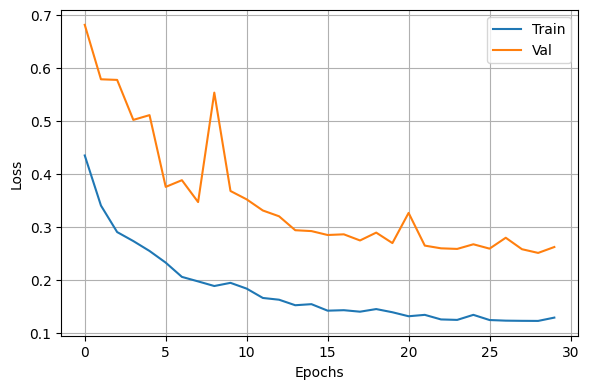

In [69]:
import matplotlib.pyplot as plt

def plot_history(history):

        plt.figure(figsize=(6, 4))
        plt.plot(history['loss'], label=f'Train')
        plt.plot(history['val_loss'], label=f'Val')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        

plot_history(history)


In [70]:
# Desescalar residuos
n_targets = dy_train.shape[-1]

pred_3d = predictions.reshape(-1, H, n_targets)
pred_2d = pred_3d.reshape(-1, n_targets)

dy_pred_2d = dy_scaler.inverse_transform(pred_2d)
dy_pred = dy_pred_2d.reshape(-1, H, n_targets)

#Reconstruir predicción absoluta
y_pred = y0_test[:, None, :] + dy_pred

y_true = y_test_real

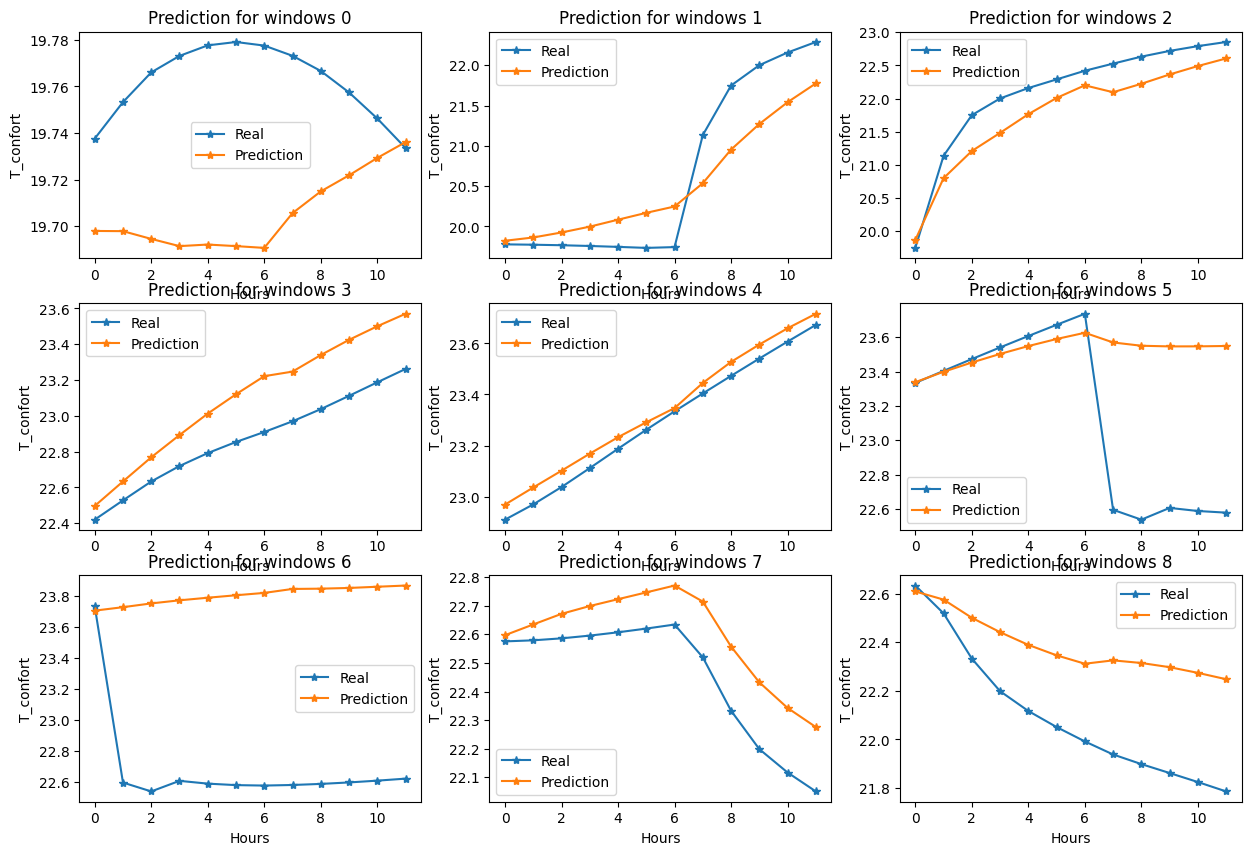

In [71]:
idx = 0  # 0:T, 1:H, 2:CO2

plt.figure(figsize=(15, 10))

idx = 0  # variable

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.title(f'Prediction for windows {i}')
    plt.plot(y_true[i][:, idx], '-*', label='Real')
    plt.plot(y_pred[i][:, idx], '-*', label='Prediction')

    plt.ylabel(target_col[idx])
    plt.xlabel('Hours')
    plt.legend()
  

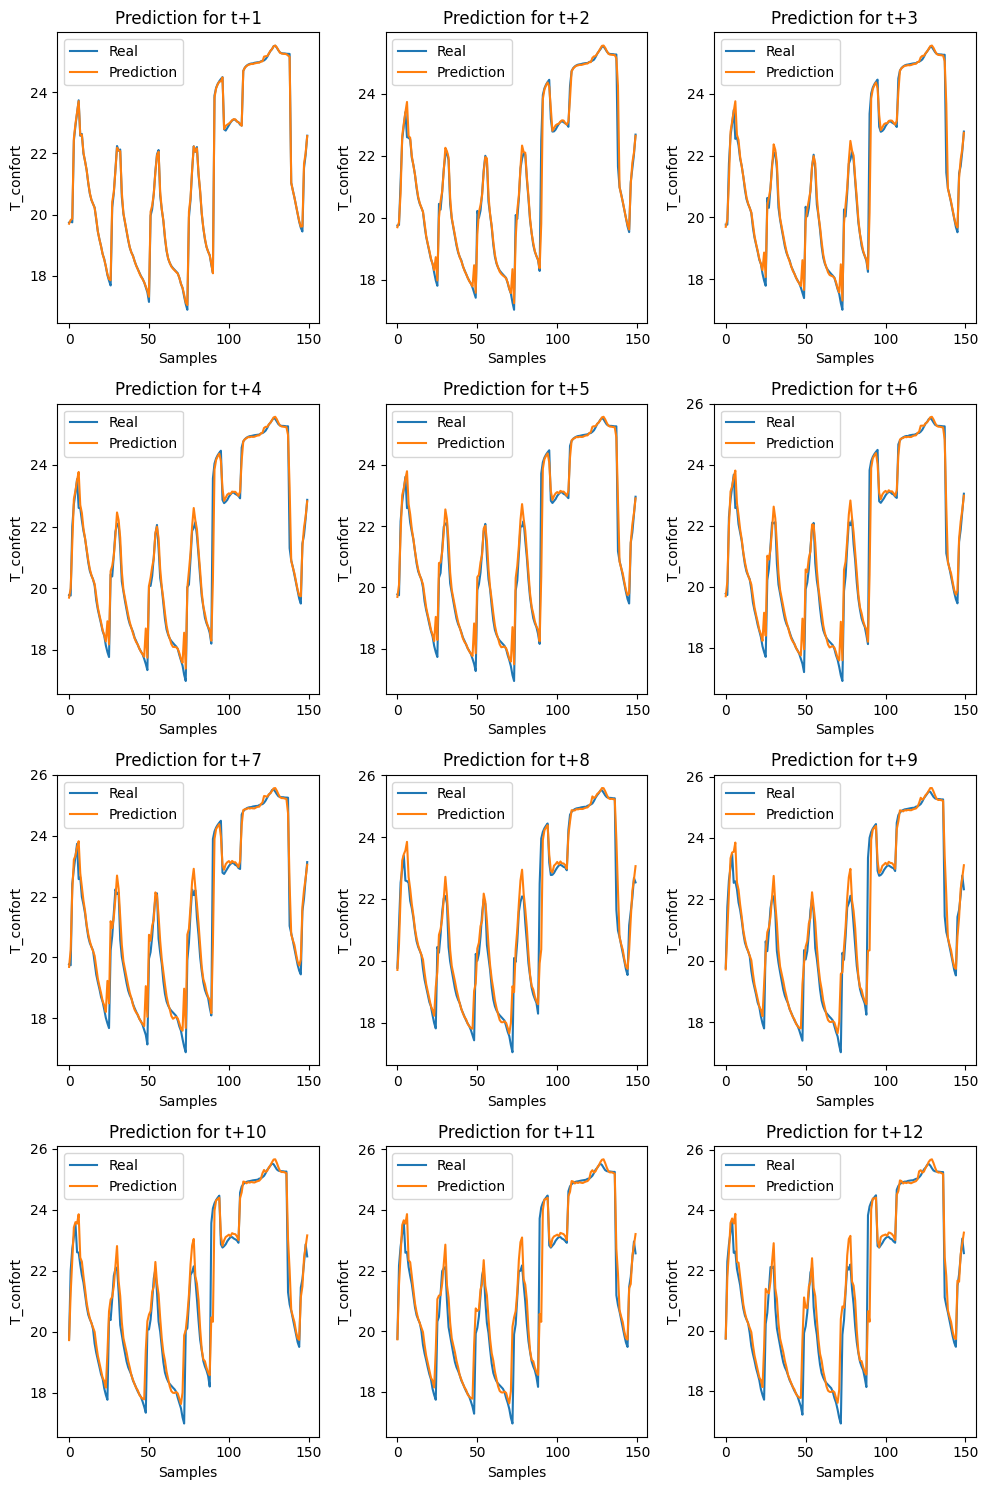

In [72]:
# Plot múltiples horizontes

plt.figure(figsize=(10, 15))

idx = 0  # variable

for i in range(H):
    plt.subplot(4,3, i+1)

    pred_series = y_pred[:150, i, idx]
    real_series = y_true[:150, i, idx]

    plt.title(f'Prediction for t+{i+1}')
    plt.plot(real_series, label='Real')
    plt.plot(pred_series, label='Prediction')

    plt.ylabel(target_col[idx])
    plt.xlabel('Samples')
    plt.legend()

plt.tight_layout()
plt.show()

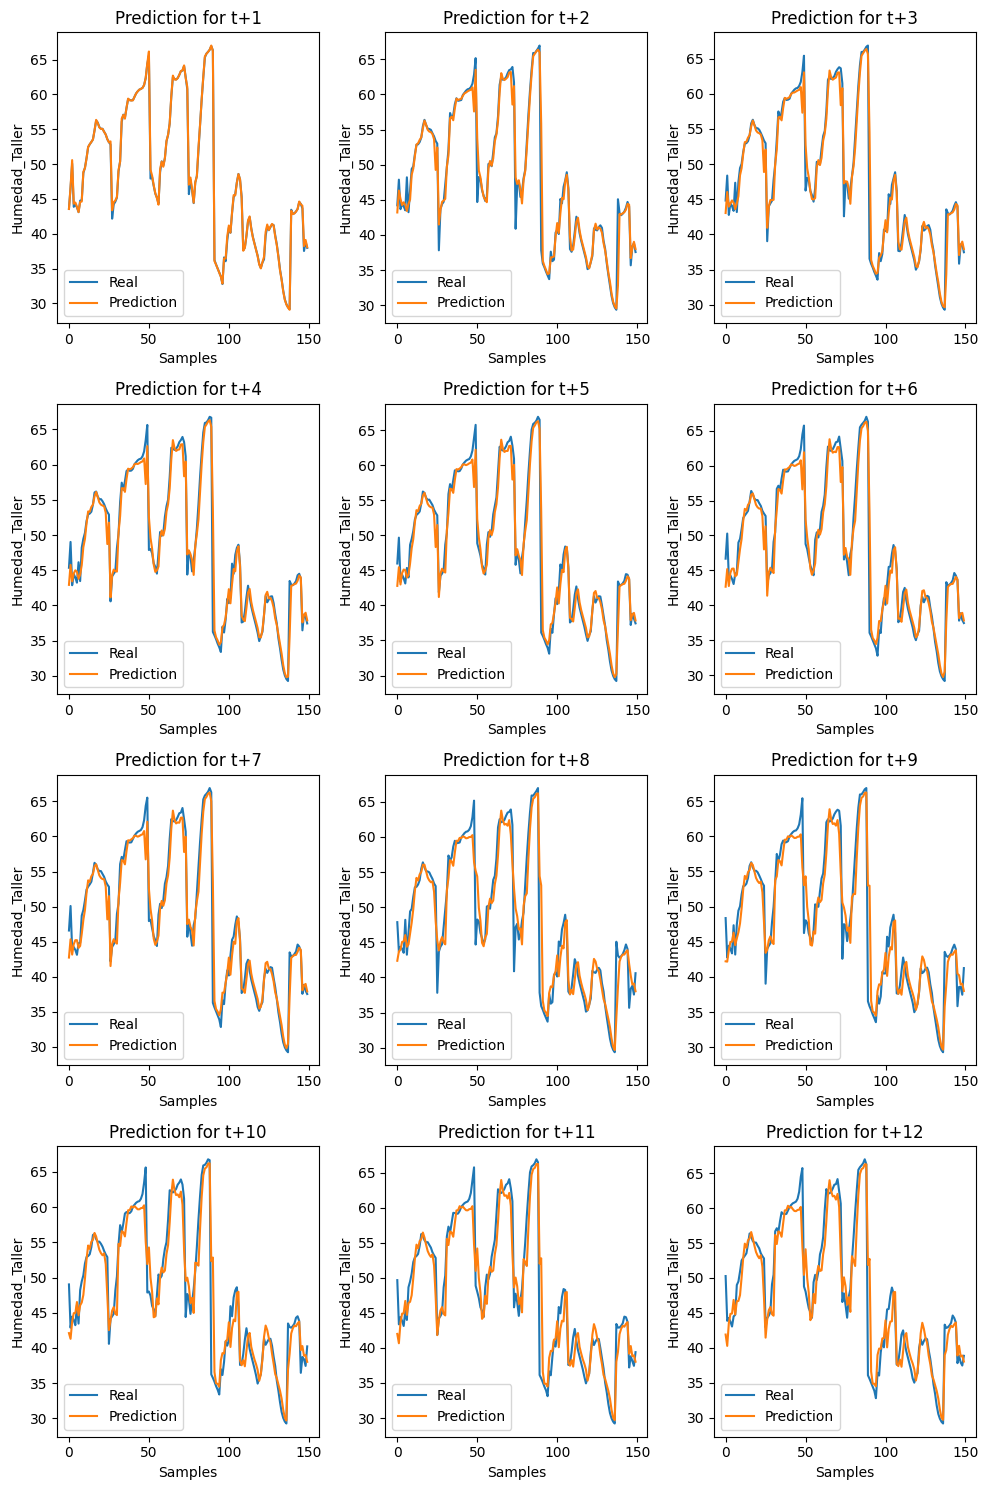

In [73]:
# Plot múltiples horizontes

plt.figure(figsize=(10, 15))

idx = 1  # variable

for i in range(H):
    plt.subplot(4, 3, i+1)

    pred_series = y_pred[:150, i, idx]
    real_series = y_true[:150, i, idx]

    plt.title(f'Prediction for t+{i+1}')
    plt.plot(real_series, label='Real')
    plt.plot(pred_series, label='Prediction')

    plt.ylabel(target_col[idx])
    plt.xlabel('Samples')
    plt.legend()

plt.tight_layout()
plt.show()

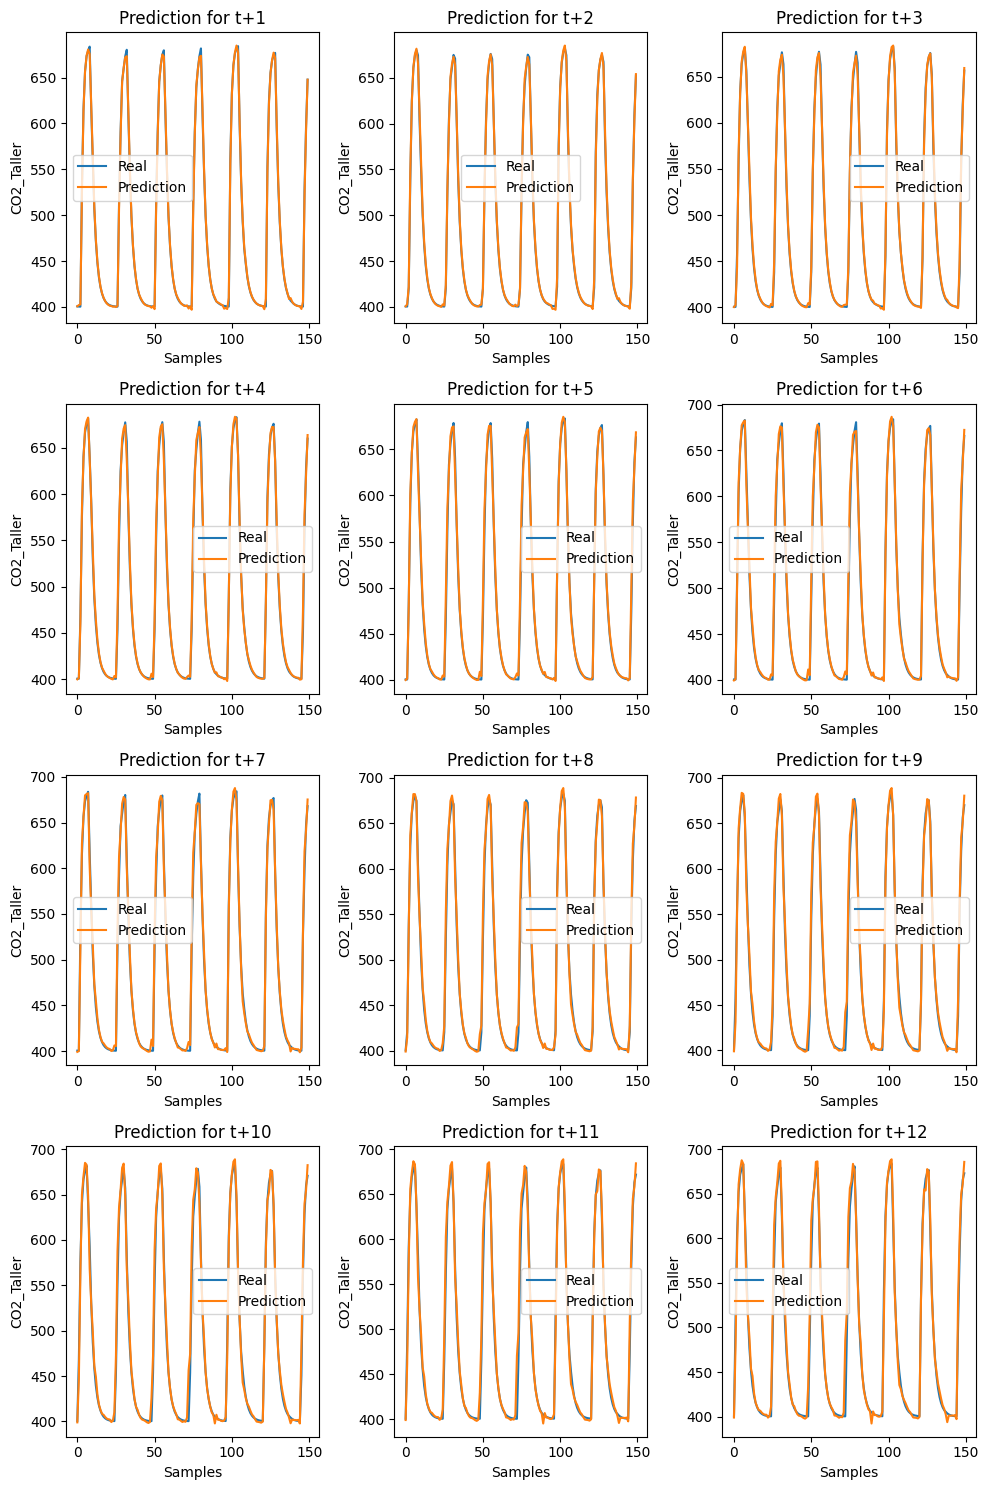

In [74]:
# Plot múltiples horizontes

plt.figure(figsize=(10, 15))

idx = 2  # variable

for i in range(H):
    plt.subplot(4,3, i+1)

    pred_series = y_pred[:150, i, idx]
    real_series = y_true[:150, i, idx]

    plt.title(f'Prediction for t+{i+1}')
    plt.plot(real_series, label='Real')
    plt.plot(pred_series, label='Prediction')

    plt.ylabel(target_col[idx])
    plt.xlabel('Samples')
    plt.legend()

plt.tight_layout()
plt.show()

In [75]:
import numpy as np

def nse(observado, simulado):
    return 1 - np.sum((simulado-observado)**2,axis = 0)/np.sum((observado-np.mean(observado,axis=0))**2,axis = 0)


In [76]:

for i in range(len(target_col)):
    print(f'NSE by hour for {target_col[i]}:')
    print(nse(y_pred[:70,:,i], y_true[:70,:,i]), '\n')


NSE by hour for T_confort:
[0.99879922 0.97749839 0.97258415 0.96949139 0.9588558  0.94644389
 0.93569669 0.93145131 0.92740079 0.92127888 0.90797179 0.89336213] 

NSE by hour for Humedad_Taller:
[0.99814849 0.93001916 0.93857389 0.93572121 0.9199388  0.89800704
 0.90477691 0.8016213  0.82117881 0.81996588 0.80808612 0.79062351] 

NSE by hour for CO2_Taller:
[0.99938509 0.99897493 0.99811863 0.99652969 0.99480263 0.99449736
 0.99528406 0.9939707  0.99256013 0.99026498 0.98800101 0.98709723] 



In [77]:
y_true.shape

(15468, 12, 3)

In [80]:
# Evaluacion del modelo en ventanas con saltos bruscos
h = 11
idx = 0

#dT_true calcula el cambio temporal entre pasos consecutivos dentro de cada secuencia.
dT_true = np.abs(y_true[:, 1:, idx] - y_true[:, :-1, idx])
threshold = np.percentile(dT_true, 90)

mask_jump = dT_true[:, h-1] > threshold
rmse_jump = np.sqrt(np.mean((y_true[mask_jump, h, idx] - y_pred[mask_jump, h, idx])**2))
rmse_nojump = np.sqrt(np.mean((y_true[~mask_jump, h, idx] - y_pred[~mask_jump, h, idx])**2))

In [81]:
print(f'RMSE en ventanas con cambios bruscos: {rmse_jump}, y sin cambios bruscos: {rmse_nojump}')

RMSE en ventanas con cambios bruscos: 0.7209383816174736, y sin cambios bruscos: 0.45112270280760935


El error en transitorios es mayor

Eso confirma que el LSTM suaviza o falla parcialmente en dinámicas rápidas. Y para control, eso pesa muchísimo más que el error promedio global.

Porque el PPO aprende sobre:

- momentos donde abrir ventana importa
- cuando el HVAC cambia estado
- cuando entra ocupación
- cuando cambia el clima exterior
- cuando el sistema se acerca al límite de confort

Y esos son justamente los eventos bruscos.

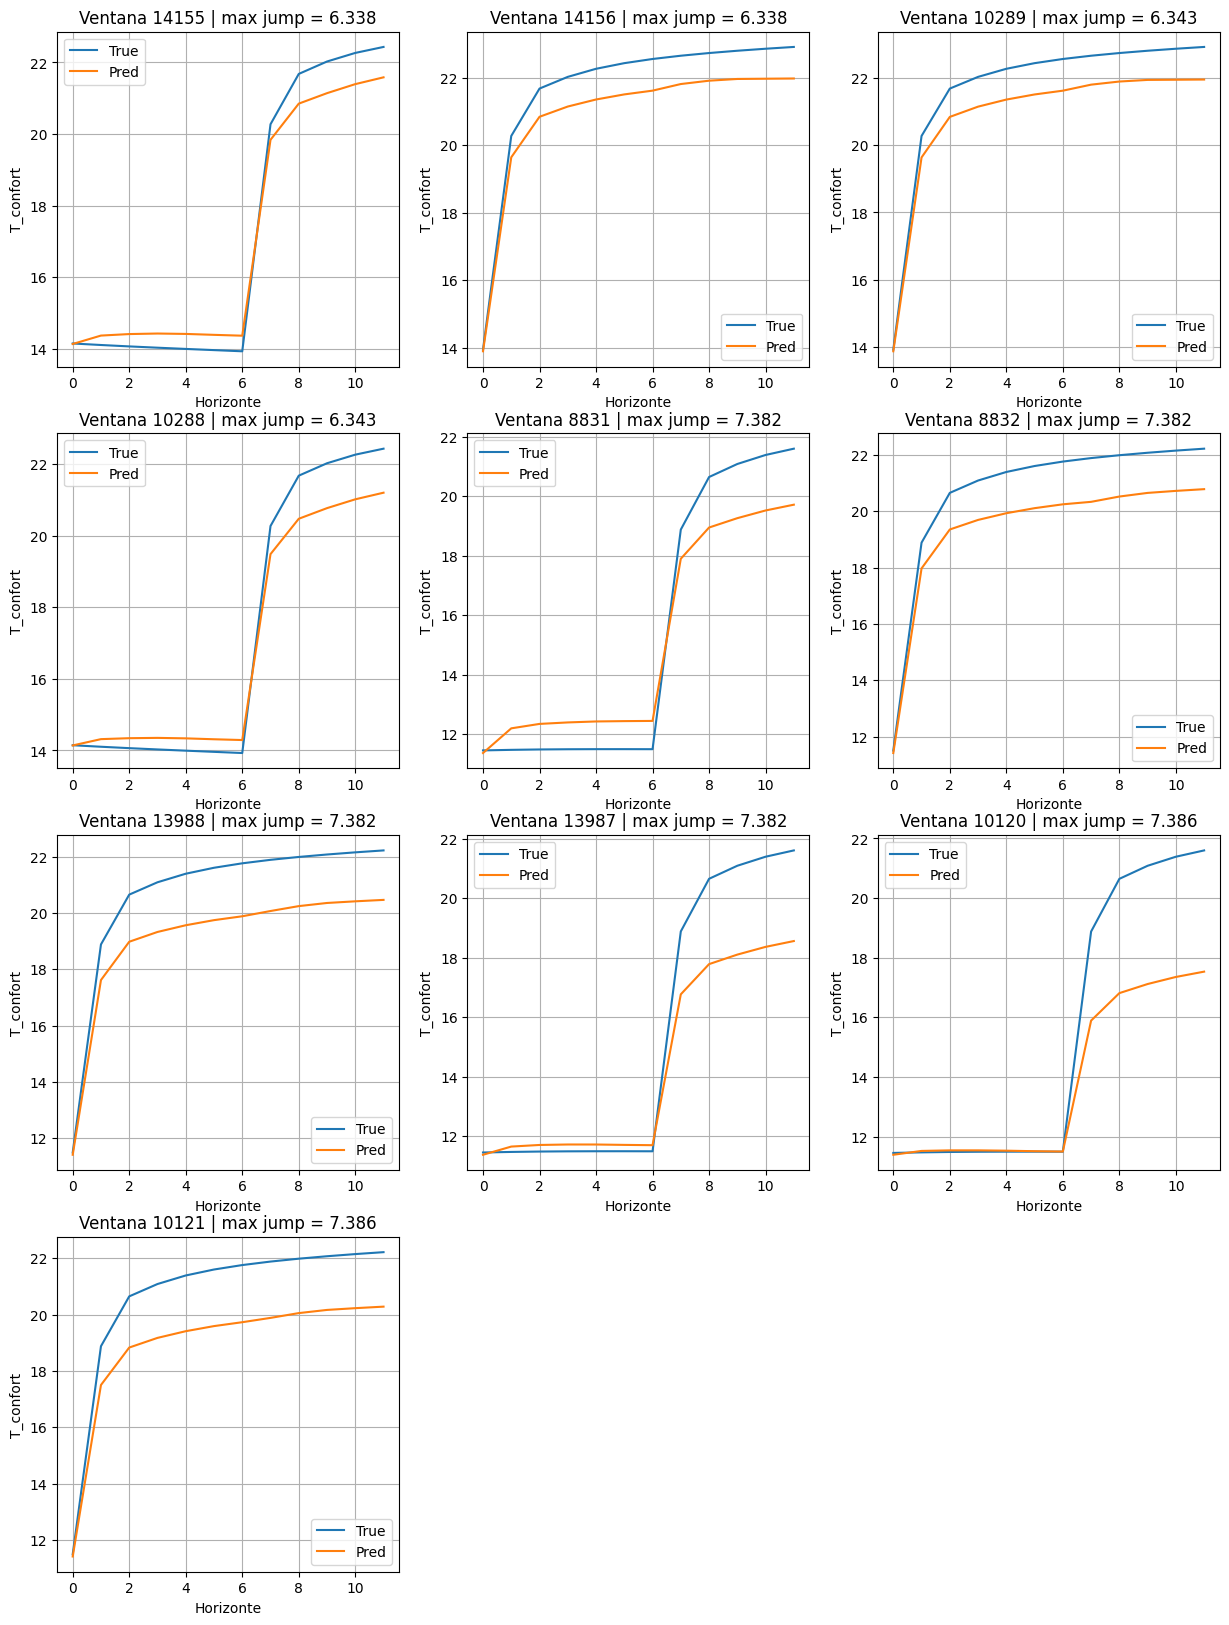

In [83]:
import numpy as np
import matplotlib.pyplot as plt

idx = 0  # ajusta si usas otro nombre

# Cambio real dentro del horizonte
dT_true = np.abs(y_true[:, 1:, idx] - y_true[:, :-1, idx])

# Máximo salto por ventana
max_jump = dT_true.max(axis=1)

# Elegimos las ventanas más bruscas
top_jump_indices = np.argsort(max_jump)[-10:]
plt.figure(figsize=(15, 20))

for j,i in enumerate(top_jump_indices):
    plt.subplot(4,3,j+1)
    plt.plot(y_true[i, :, idx], label="True")
    plt.plot(y_pred[i, :, idx], label="Pred")
    plt.title(f"Ventana {i} | max jump = {max_jump[i]:.3f}")
    plt.xlabel("Horizonte")
    plt.ylabel("T_confort")
    plt.legend()
    plt.grid(True)
plt.show()

In [86]:
idx = 0

delta_true = y_true[:, -1, idx] - y_true[:, 0, idx]
delta_pred = y_pred[:, -1, idx] - y_pred[:, 0, idx]

print("True delta mean:", np.mean(np.abs(delta_true)))
print("Pred delta mean:", np.mean(np.abs(delta_pred)))

print("Ratio pred/true:",
      np.mean(np.abs(delta_pred)) / np.mean(np.abs(delta_true)))

True delta mean: 0.6183120133596071
Pred delta mean: 0.5354503384153404
Ratio pred/true: 0.8659872796356703


### Comapracion con Baseline de persistencia

In [87]:
y_pred_baseline = np.repeat(y0_test[:, None, :], H, axis=1)

for j, var_name in enumerate(target_col):
    print(f"\nVariable: {var_name}")

    for h in range(H):
        mae_baseline = np.mean(
            np.abs(y_test_real[:, h, j] - y_pred_baseline[:, h, j])
        )

        mae_model = np.mean(
            np.abs(y_test_real[:, h, j] - y_pred[:, h, j])
        )

        print(
            f"H+{h+1} | baseline: {mae_baseline:.3f} | residual model: {mae_model:.3f}"
        )


Variable: T_confort
H+1 | baseline: 0.032 | residual model: 0.033
H+2 | baseline: 0.162 | residual model: 0.089
H+3 | baseline: 0.220 | residual model: 0.107
H+4 | baseline: 0.260 | residual model: 0.120
H+5 | baseline: 0.298 | residual model: 0.136
H+6 | baseline: 0.333 | residual model: 0.151
H+7 | baseline: 0.364 | residual model: 0.166
H+8 | baseline: 0.474 | residual model: 0.202
H+9 | baseline: 0.529 | residual model: 0.213
H+10 | baseline: 0.570 | residual model: 0.223
H+11 | baseline: 0.607 | residual model: 0.235
H+12 | baseline: 0.642 | residual model: 0.247

Variable: Humedad_Taller
H+1 | baseline: 0.093 | residual model: 0.127
H+2 | baseline: 0.888 | residual model: 0.575
H+3 | baseline: 1.139 | residual model: 0.712
H+4 | baseline: 1.343 | residual model: 0.836
H+5 | baseline: 1.535 | residual model: 0.963
H+6 | baseline: 1.716 | residual model: 1.094
H+7 | baseline: 1.643 | residual model: 1.051
H+8 | baseline: 2.442 | residual model: 1.515
H+9 | baseline: 2.637 | residu

In [88]:
def write_action_into_last_step(X, action, idx_heat, idx_cool, x_scaler):
    X_new = X.copy()

    # acción ya en escala real
    a_heat = float(action[0])
    a_cool = float(action[1])

    # escalar para meter en X
    heat_scaled = (a_heat - x_scaler.mean_[idx_heat]) / x_scaler.scale_[idx_heat]
    cool_scaled = (a_cool - x_scaler.mean_[idx_cool]) / x_scaler.scale_[idx_cool]

    X_new[0, -1, idx_heat] = heat_scaled
    X_new[0, -1, idx_cool] = cool_scaled

    return X_new


def predict_horizon_real(model, X, x_scaler, dy_scaler, H, n_targets, idx_targets_in_X):
    """
    X: (1, sequence_length, n_features), escalado con x_scaler

    Devuelve:
        y_abs_real:   (H, n_targets)
        y_abs_scaled: (H, n_targets)
    """

    # 1) Modelo predice deltas escalados
    dy_pred = model.predict(X, verbose=0)

    # Sirve tanto si sale (1, H, n_targets) como si sale (1, H*n_targets)
    dy_scaled = dy_pred.reshape(H, n_targets)

    # 2) Desescalar deltas
    dy_real = dy_scaler.inverse_transform(dy_scaled)

    # 3) Último valor real observado
    y0_scaled = X[0, -1, idx_targets_in_X]

    y0_real = (
        y0_scaled * x_scaler.scale_[idx_targets_in_X]
        + x_scaler.mean_[idx_targets_in_X]
    )

    # 4) Reconstruir valores absolutos reales
    y_abs_real = y0_real + dy_real

    # 5) Reescalar valores absolutos para reinyectar en X
    y_abs_scaled = (
        y_abs_real - x_scaler.mean_[idx_targets_in_X]
    ) / x_scaler.scale_[idx_targets_in_X]

    return y_abs_real.astype(np.float32), y_abs_scaled.astype(np.float32)

In [125]:
# Test de sensibilidad del LSTM
cols_action = [
    "termostatos_Taller_Heating",
    "termostatos_Taller_Cooling"
]

idx_action = [feature_cols.index(c) for c in cols_action]

idx_heat = idx_action[0]
idx_cool = idx_action[1]

# índices de targets dentro de X
idx_targets_in_X = [feature_cols.index(c) for c in target_col]

n_targets = len(target_col)


# ventana inicial 
X0 = X_test_scaled[0].copy()

X0 = X0[None, :, :]   # (1, 144, 110)

Actions = np.array([
    [0, 50],
    [18, 30],
    [20, 24],
    [20, 28],
    [22, 26],
    [24, 24],
    [24, 26],
    [26, 26],
    [28, 28],
    [30, 30],
    [50, 50],
])

predictions = np.zeros((len(Actions),H))

for i,action in enumerate(Actions):

    X_action = write_action_into_last_step(
        X0,
        action,
        idx_heat,
        idx_cool,
        x_scaler
    )

    y_real, y_scaled = predict_horizon_real(
        model,
        X_action,
        x_scaler,
        dy_scaler,
        H,
        n_targets,
        idx_targets_in_X
    )

#     print("\n================================")
#     print("ACTION:", action)

#     print("T_confort horizon:")
#     print(
#         y_real[:, target_col.index("T_confort")]
#     )
    predictions[i,:]=y_real[:, target_col.index("T_confort")]

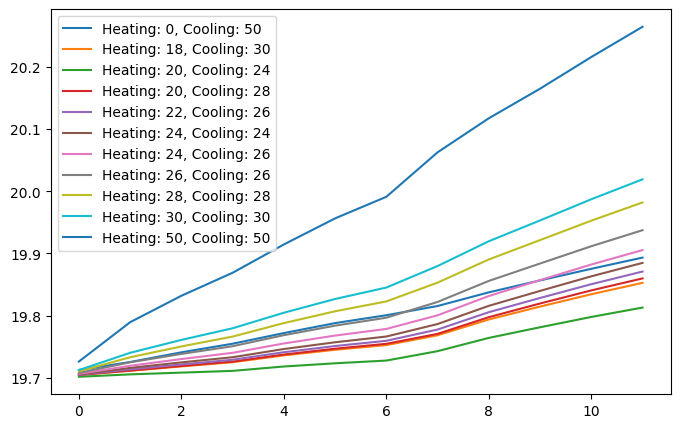

In [127]:
plt.figure(figsize=(8, 5))

for i,action in enumerate(Actions):

    plt.plot(predictions[i,:],label = f'Heating: {action[0]}, Cooling: {action[1]}')
    

plt.legend()    

In [90]:
idx_T = feature_cols.index("T_confort")



# Temperatura actual = último timestep de cada ventana
T0_all = X_test[:, -1, idx_T]

# Índices de estados fríos y calientes
cold_ids = np.where(T0_all < 19)[0]
hot_ids  = np.where(T0_all > 25)[0]
comfort_ids = np.where((T0_all >= 20) & (T0_all <= 24))[0]

In [91]:
T0_all.max()

np.float64(27.036368265747)

In [92]:
test_df["T_confort"].max(),val_df["T_confort"].max(),train_df["T_confort"].max()

(np.float64(27.10822019703744),
 np.float64(31.908839353698585),
 np.float64(32.51607240428192))

In [128]:
i0 = cold_ids[0]      # estado frío real

X0 = X_test_scaled[i0:i0+1].copy()

print("T0 real:", T0_all[i0])

Actions = np.array([
    [0, 50],    # HVAC apagado
    [18, 30],   # calefacción baja
    [20, 30],
    [22, 30],
    [24, 30],
    [26, 30],
    [30, 30],   # calefacción fuerte
    [50, 50],   # extremo
])

predictions = np.zeros((len(Actions),H))

for i,action in enumerate(Actions):

    X_action = write_action_into_last_step(
        X0,
        action,
        idx_heat,
        idx_cool,
        x_scaler
    )

    y_real, y_scaled = predict_horizon_real(
        model,
        X_action,
        x_scaler,
        dy_scaler,
        H,
        n_targets,
        idx_targets_in_X
    )

#     print("\n================================")
#     print("ACTION:", action)

#     print("T_confort horizon (Estados fríos T confort < 19):")
#     print(
#         y_real[:, target_col.index("T_confort")]
#     )
    predictions[i,:]=y_real[:, target_col.index("T_confort")]

T0 real: 18.751796954793484


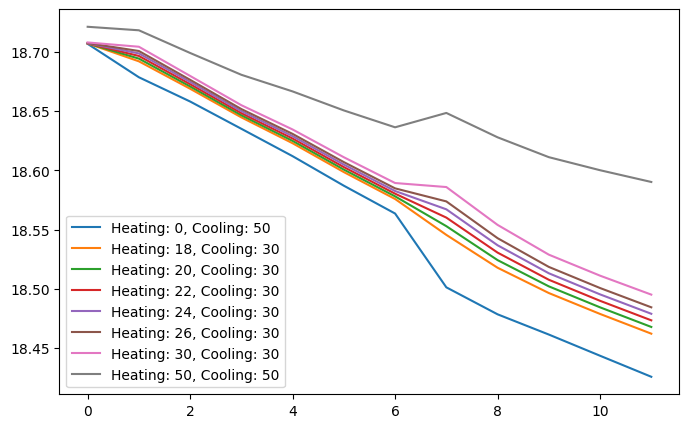

In [129]:
plt.figure(figsize=(8, 5))

for i,action in enumerate(Actions):

    plt.plot(predictions[i,:],label = f'Heating: {action[0]}, Cooling: {action[1]}')
    

plt.legend()    

In [93]:
df_2["T_confort"].max()

np.float64(32.51607240428192)

In [130]:
i0 = hot_ids[0]     # estado caliente real

X0 = X_test_scaled[i0:i0+1].copy()

print("T0 real:", T0_all[i0])


Actions = np.array([
    [0, 50],    # cooling apagado
    [18, 30],
    [18, 28],
    [18, 26],
    [18, 24],
    [18, 22],
    [18, 20],
    [0, 0],     # extremo cooling fuerte si tu codificación lo permite
])

predictions = np.zeros((len(Actions),H))

for i,action in enumerate(Actions):

    X_action = write_action_into_last_step(
        X0,
        action,
        idx_heat,
        idx_cool,
        x_scaler
    )

    y_real, y_scaled = predict_horizon_real(
        model,
        X_action,
        x_scaler,
        dy_scaler,
        H,
        n_targets,
        idx_targets_in_X
    )

#     print("\n================================")
#     print("ACTION:", action)

#     print("T_confort horizon (Estados calientes T confort > 25):")
#     print(
#         y_real[:, target_col.index("T_confort")]
#     )
    predictions[i,:]=y_real[:, target_col.index("T_confort")]

T0 real: 25.00245283551174


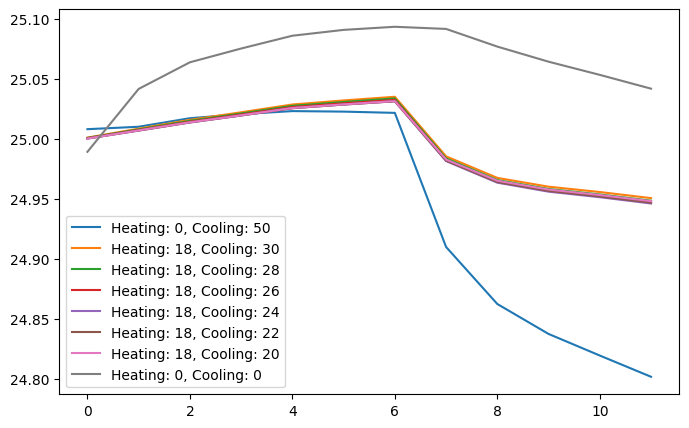

In [131]:
plt.figure(figsize=(8, 5))

for i,action in enumerate(Actions):

    plt.plot(predictions[i,:],label = f'Heating: {action[0]}, Cooling: {action[1]}')
    

plt.legend()  

In [132]:
i0 = comfort_ids[0] # estado confortable real

X0 = X_test_scaled[i0:i0+1].copy()

print("T0 real:", T0_all[i0])

Actions = np.array([
   [0, 50],
    [18, 30],
    [20, 28],
    [22, 26],
    [24, 24],
    [26, 26],
    [30, 30],
    [50, 50],
])


predictions = np.zeros((len(Actions),H))

for i,action in enumerate(Actions):

    X_action = write_action_into_last_step(
        X0.copy(),
        action,
        idx_heat,
        idx_cool,
        x_scaler
    )

    y_real, y_scaled = predict_horizon_real(
        model,
        X_action,
        x_scaler,
        dy_scaler,
        H,
        n_targets,
        idx_targets_in_X
    )

#     print("\n================================")
#     print("ACTION:", action)

#     print("T_confort horizon (Estados confortables T confort 20-24):")
#     print(
#         y_real[:, target_col.index("T_confort")]
#     )
    predictions[i,:]=y_real[:, target_col.index("T_confort")]

T0 real: 22.289004195856


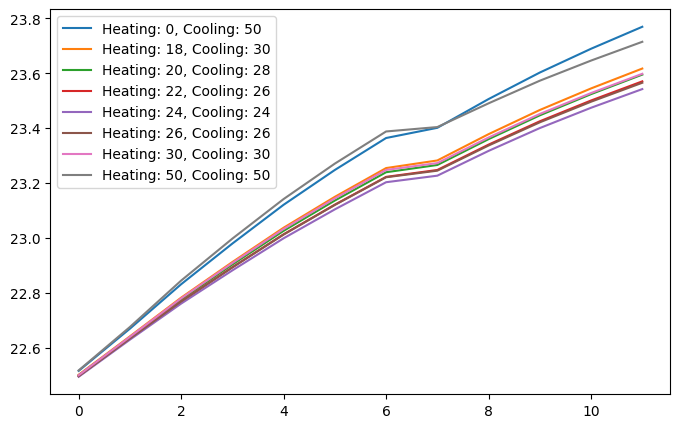

In [133]:
plt.figure(figsize=(8, 5))

for i,action in enumerate(Actions):

    plt.plot(predictions[i,:],label = f'Heating: {action[0]}, Cooling: {action[1]}')
    

plt.legend()  

In [97]:
print("y0 real:", y0_test[i0, target_col.index("T_confort")])
print("y_true real:", y_test_real[i0, :, target_col.index("T_confort")])

y0 real: 22.289004195856
y_true real: [22.41978567 22.52754773 22.63309714 22.71954098 22.79182257 22.85398728
 22.90974116 22.96950627 23.03745998 23.11167929 23.1873922  23.26196448]


In [98]:
idx_T_X = feature_cols.index("T_confort")
idx_T_y = target_col.index("T_confort")

print("T0 desde X_test:", X_test[i0, -1, idx_T_X])
print("T0 desde y0_test:", y0_test[i0, idx_T_y])
print("Futuro real:", y_test_real[i0, :, idx_T_y])

T0 desde X_test: 22.289004195856
T0 desde y0_test: 22.289004195856
Futuro real: [22.41978567 22.52754773 22.63309714 22.71954098 22.79182257 22.85398728
 22.90974116 22.96950627 23.03745998 23.11167929 23.1873922  23.26196448]


# Análisis de sensibilidad del LSTM frente a acciones de control

## Objetivo

El objetivo de estos tests fue evaluar si el modelo LSTM realmente aprendió la relación causal entre las acciones de control HVAC y la evolución de la temperatura de confort (`T_confort`), o si simplemente está extrapolando la dinámica natural del edificio basada en clima, inercia térmica y autocorrelación temporal.

La validación clásica con métricas tipo MAE/RMSE/NSE no es suficiente para RL, porque un modelo puede predecir muy bien trayectorias naturales y aun así ignorar completamente el efecto de las acciones.

Por eso se realizaron tests de sensibilidad fijando un mismo estado inicial y variando únicamente las acciones.

---

# Resultado general

El modelo:

- es estable en rollout autoregresivo,
- no presenta explosiones ni drift absurdo,
- mantiene coherencia temporal,
- reproduce correctamente tendencias térmicas generales,

pero:

- la sensibilidad frente a las acciones parece demasiado baja,
- las trayectorias están dominadas por patrones exógenos (clima/hora/inercia),
- el efecto causal del control HVAC parece amortiguado.

La conclusión preliminar es que el LSTM aprendió muy bien la dinámica pasiva del edificio, pero todavía no está claro que haya aprendido correctamente el impacto real del control.

---

# Caso 1 — Estados fríos

Estado inicial:

```python
T0 = 18.75
```

Incluso utilizando acciones extremas:

```python
[50, 50]
```

la temperatura continúa descendiendo:

```python
18.72 -> 18.59
```

Mientras que con acciones bajas:

```python
[0, 50]
```

la trayectoria termina en:

```python
18.42
```

La diferencia total entre acciones extremas y acciones bajas es aproximadamente:

```python
0.16 °C
```

a horizonte 12.

Esto es una sensibilidad muy pequeña para un sistema HVAC actuando durante múltiples pasos temporales.

## Interpretación

El modelo parece asumir que:

```text
la dinámica térmica depende principalmente de la inercia/clima,
y las acciones tienen un efecto secundario.
```

No se observan inversiones físicas absurdas ni inestabilidad, pero sí una fuerte amortiguación del efecto del control.

---

# Caso 2 — Estados calientes

Estado inicial:

```python
T0 = 25.00
```

El modelo sí reconoce correctamente la dirección del enfriamiento:

- acciones de cooling producen descenso,
- ausencia de control mantiene temperaturas más altas.

Por ejemplo:

```python
[0,0]      -> 25.04
[18,20]    -> 24.95
[0,50]     -> 24.80
```

Sin embargo, nuevamente las diferencias son pequeñas:

```python
ΔT ≈ 0.1 - 0.25 °C
```

a horizonte 12.

## Observación importante

En prácticamente todas las trayectorias aparece una caída brusca alrededor de H+8, independientemente de la acción aplicada.

Esto sugiere que el modelo está muy influenciado por patrones horarios/climáticos aprendidos del dataset y no tanto por las acciones de control.

---

# Caso 3 — Estados confortables

Estado inicial:

```python
T0 = 22.29
```

Todas las trayectorias evolucionan hacia calentamiento:

```python
22.29 -> 23.5 - 23.8
```

independientemente de la acción.

Las acciones modifican muy poco la evolución final.

Por ejemplo:

| Acción | T(H+12) |
|---|---|
| [24,24] | 23.54 |
| [22,26] | 23.57 |
| [20,28] | 23.59 |
| [30,30] | 23.60 |
| [18,30] | 23.62 |
| [50,50] | 23.71 |
| [0,50] | 23.77 |

La diferencia total máxima entre trayectorias es:

```python
≈ 0.23 °C
```

Lo más llamativo es que algunas relaciones no parecen físicamente limpias:

```text
[0,50] calienta más que [50,50]
```

o:

```text
[24,24] enfría más que [18,30]
```

Esto sugiere que el modelo no aprendió una relación causal fuerte y consistente entre acción y respuesta térmica.

---

# Conclusión general

El LSTM:

- modela bien la evolución natural del sistema,
- tiene rollout estable,
- reproduce tendencias temporales razonables,
- supera claramente al baseline persistente,

pero:

- las acciones HVAC tienen muy poca influencia sobre la predicción,
- la dinámica parece estar dominada por clima e inercia,
- la sensibilidad causal probablemente es insuficiente para PPO robusto.

En otras palabras:

```text
el modelo parece excelente para forecasting,
pero todavía no está claro que sea suficientemente bueno
como entorno de control para RL.
```

---

# Problema potencial para PPO

Si el LSTM cree que:

```text
las acciones apenas modifican la temperatura
```

entonces PPO puede aprender políticas incorrectas:

- no actuar,
- actuar arbitrariamente,
- sobreutilizar HVAC,
- ignorar ventilación,
- explotar errores del modelo.

El riesgo principal es que el agente optimice un entorno cuya física de control está amortiguada respecto al sistema real.

---

# Próximo paso crítico

Comparar directamente contra EnergyPlus.

Usar:

- mismo estado inicial,
- mismas secuencias de acciones,
- mismo horizonte temporal,

y comparar:

```text
EnergyPlus vs LSTM
```

para trayectorias completas.

Por ejemplo:

```python
[0,0]
[20,20]
[50,50]
```

Si EnergyPlus produce diferencias térmicas mucho mayores que el LSTM, entonces el modelo no está aprendiendo correctamente el efecto causal del control.

Si ambos producen sensibilidades similares, entonces el comportamiento observado es físicamente coherente y el problema no está en el LSTM sino en la dinámica real del edificio.

---

# Interpretación final

Actualmente el modelo parece haber aprendido:

```text
dinámica térmica natural > dinámica de control
```

y esto es extremadamente común en building RL, porque la temperatura interior tiene muchísima autocorrelación temporal.

El LSTM minimiza fácilmente la loss extrapolando tendencias térmicas sin necesidad de aprender correctamente el impacto de las acciones HVAC.